# Flow Matching on STL-10 (PyTorch)

Beginner-friendly but theoretically correct implementation.

Paper grounding: Flow Matching for Generative Modeling (Lipman et al., arXiv:2210.02747v2).

Training objective:
- Sample real image x1 from data
- Sample z0 ~ N(0, I)
- Sample t ~ Uniform(0, 1)
- Build xt = (1 - t) z0 + t x1
- Target velocity u = x1 - z0
- Minimize MSE(v_theta(xt, t), u)

Sampling:
- Solve dx/dt = v_theta(x, t) from t=0 to t=1 with Euler steps

In [7]:
!pip install -q torchmetrics torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 10.8 MB/s eta 0:00:00


In [8]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
print("FID/IS imports OK")


FID/IS imports OK


In [1]:
import math
import os
import random
import json
import time
import copy
import sys
from datetime import datetime
from dataclasses import dataclass, asdict
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
# Environment-aware path setup (Colab + local)
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    PROJECT_ROOT = Path("/content/drive/MyDrive/Nom_Du_Projet")
else:
    PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "data"
RUN_ROOT = PROJECT_ROOT / "runs"

for d in [PROJECT_ROOT, DATA_ROOT, RUN_ROOT]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUN_ROOT:", RUN_ROOT)

@dataclass
class Config:
    # Absolute project paths
    project_root: str = str(PROJECT_ROOT)
    data_root: str = str(DATA_ROOT)
    run_root: str = str(RUN_ROOT)

    # Dataset
    dataset_name: str = "stl10"
    stl_split: str = "train+unlabeled"
    image_size: int = 96

    # Training
    batch_size: int = 64
    num_workers: int = 2
    lr: float = 2e-4
    weight_decay: float = 1e-5
    epochs: int = 100
    print_every: int = 100
    sample_steps: int = 50
    n_sample_vis: int = 64
    use_ema: bool = True
    ema_decay: float = 0.999

    # Tracking / experiment management
    run_prefix: str = "cfm"
    save_every_epoch: int = 1
    progress_nfe: int = 50
    progress_num_images: int = 64
    fixed_vis_seed: int = 123

    # Resume training from checkpoint (example: ".../runs/cfm_xxx/checkpoints/last.pt")
    # If empty, training starts a fresh run.
    resume_checkpoint: str = ""
    auto_resume_latest: bool = True

    # Final comparison export (for FID/IS/runtime)
    eval_nfes: tuple = (10, 20, 50, 100)
    eval_num_images: int = 5000
    eval_batch_size: int = 100
    eval_seed: int = 2026

# You can reduce epochs for quick tests, then increase later.
cfg = Config()
print(cfg)




Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Nom_Du_Projet
RUN_ROOT: /content/drive/MyDrive/Nom_Du_Projet/runs
Config(project_root='/content/drive/MyDrive/Nom_Du_Projet', data_root='/content/drive/MyDrive/Nom_Du_Projet/data', run_root='/content/drive/MyDrive/Nom_Du_Projet/runs', dataset_name='stl10', stl_split='train+unlabeled', image_size=96, batch_size=64, num_workers=2, lr=0.0002, weight_decay=1e-05, epochs=100, print_every=100, sample_steps=50, n_sample_vis=64, use_ema=True, ema_decay=0.999, run_prefix='cfm', save_every_epoch=1, progress_nfe=50, progress_num_images=64, fixed_vis_seed=123, resume_checkpoint='', auto_resume_latest=True, eval_nfes=(10, 20, 50, 100), eval_num_images=5000, eval_batch_size=100, eval_seed=2026)


In [9]:
def sinusoidal_time_embedding(t: torch.Tensor, dim: int) -> torch.Tensor:
    """Role: convert scalar time t into a vector embedding the network can use."""
    # Map scalar time t to a higher-dimensional vector so the network can use time information
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device).float() / max(half - 1, 1))
    angles = t[:, None] * freqs[None, :] * 2 * math.pi
    emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


class TimeResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, t_dim: int):
        """Role: build one residual conv block conditioned by time embedding."""
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.t_proj = nn.Linear(t_dim, out_ch)
        # Skip connection helps optimization (residual learning)
        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        """Role: transform features while injecting time information."""
        h = self.conv1(x)
        h = self.norm1(h)
        # Inject time embedding as a bias-like term in feature maps
        h = h + self.t_proj(t_emb)[:, :, None, None]
        h = F.silu(h)
        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)
        return h + self.skip(x)


class SimpleFlowUNet(nn.Module):
    def __init__(self, in_ch: int = 3, base_ch: int = 64, t_dim: int = 128):
        """Role: build a small U-Net that predicts velocity v_theta(x, t)."""
        super().__init__()
        self.t_dim = t_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(t_dim, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )

        # Encoder: 32x32 -> 16x16 -> 8x8
        self.enc1 = TimeResBlock(in_ch, base_ch, t_dim)
        self.down1 = nn.Conv2d(base_ch, base_ch, kernel_size=4, stride=2, padding=1)
        self.enc2 = TimeResBlock(base_ch, base_ch * 2, t_dim)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, kernel_size=4, stride=2, padding=1)
        self.mid = TimeResBlock(base_ch * 2, base_ch * 2, t_dim)

        # Decoder with skip concatenations from encoder
        self.up1 = TimeResBlock(base_ch * 4, base_ch * 2, t_dim)
        self.up2 = TimeResBlock(base_ch * 3, base_ch, t_dim)
        self.out = nn.Conv2d(base_ch, in_ch, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """Role: output a velocity tensor with same shape as input image x."""
        t_emb = sinusoidal_time_embedding(t, self.t_dim)
        t_emb = self.time_mlp(t_emb)

        x1 = self.enc1(x, t_emb)
        x2 = self.enc2(self.down1(x1), t_emb)
        x3 = self.mid(self.down2(x2), t_emb)

        h = F.interpolate(x3, scale_factor=2, mode="nearest")
        h = torch.cat([h, x2], dim=1)
        h = self.up1(h, t_emb)

        h = F.interpolate(h, scale_factor=2, mode="nearest")
        h = torch.cat([h, x1], dim=1)
        h = self.up2(h, t_emb)

        # Output is predicted velocity field v_theta(x, t), same shape as x
        return self.out(h)

In [4]:
transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    # Normalize images to [-1, 1], which matches our Gaussian-noise scale better.
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_set = datasets.STL10(
    root=cfg.data_root,
    split=cfg.stl_split,
    transform=transform,
    download=True,
)

train_loader = DataLoader(
    train_set,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

print("Dataset:", cfg.dataset_name, "| Split:", cfg.stl_split)
print("Train size:", len(train_set), "| Steps per epoch:", len(train_loader))

100%|██████████| 2.64G/2.64G [03:09<00:00, 13.9MB/s] 


Dataset: stl10 | Split: train+unlabeled
Train size: 105000 | Steps per epoch: 1640


In [10]:
def flow_matching_loss(model: nn.Module, x1: torch.Tensor):
    """Role: compute one minibatch CFM loss used to train the velocity model."""
    # CFM objective (paper Eq. (9)): regress v_theta(x_t, t) to a conditional target u_t(x_t | x1)
    # We use the straight OT-style path x_t = (1 - t) x0 + t x1 (Section 4 special path choice)
    # On this path, d x_t / dt = x1 - x0, so the supervision target is constant along t
    b = x1.size(0)

    # x0 is sampled from the source distribution (standard Gaussian noise)
    z0 = torch.randn_like(x1)

    # One random time per sample in the batch
    t = torch.rand(b, device=x1.device)
    t_view = t[:, None, None, None]

    # Interpolation point between noise (t=0) and data (t=1)
    xt = (1.0 - t_view) * z0 + t_view * x1
    target_u = x1 - z0

    pred_u = model(xt, t)
    loss = F.mse_loss(pred_u, target_u)
    return loss

In [11]:
model = SimpleFlowUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)


def init_ema_model(src_model: nn.Module) -> nn.Module:
    """Role: create a detached EMA model clone used only for sampling."""
    ema = copy.deepcopy(src_model).to(device)
    ema.eval()
    for p in ema.parameters():
        p.requires_grad_(False)
    return ema

@torch.no_grad()
def update_ema(ema_model: nn.Module, src_model: nn.Module, decay: float):
    """Role: update EMA parameters from current training model."""
    for ema_p, src_p in zip(ema_model.parameters(), src_model.parameters()):
        ema_p.data.mul_(decay).add_(src_p.data, alpha=1.0 - decay)

ema_model = init_ema_model(model)
sample_model = ema_model if cfg.use_ema else model

def load_last_jsonl_record(path: Path):
    """Role: return last JSON object from a JSONL log file, or None if file is empty."""
    if (not path.exists()) or path.stat().st_size == 0:
        return None
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    for line in reversed(lines):
        s = line.strip()
        if s:
            return json.loads(s)
    return None


# Setup run context: new run or resume existing run.
start_epoch = 1
history = []
best_loss = float("inf")
global_step = 0
resumed = False
resume_ckpt_path = None

def find_latest_checkpoint(run_root: Path, run_prefix: str):
    """Role: return the most recent last.pt checkpoint for a run prefix, or None."""
    candidates = sorted(
        Path(run_root).glob(f"{run_prefix}_*/checkpoints/last.pt"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    return candidates[0] if candidates else None

resume_candidate = cfg.resume_checkpoint.strip()
if resume_candidate:
    resume_ckpt_path = Path(resume_candidate)
elif cfg.auto_resume_latest:
    resume_ckpt_path = find_latest_checkpoint(Path(cfg.run_root), cfg.run_prefix)
    if resume_ckpt_path is not None:
        print(f"[Auto-resume] Using latest checkpoint: {resume_ckpt_path}")

if resume_ckpt_path is not None:
    if not resume_ckpt_path.exists():
        raise FileNotFoundError(f"Resume checkpoint not found: {resume_ckpt_path}")

    resume_ckpt = torch.load(resume_ckpt_path, map_location=device)
    model.load_state_dict(resume_ckpt["model_state_dict"])
    optimizer.load_state_dict(resume_ckpt["optimizer_state_dict"])

    if cfg.use_ema and (resume_ckpt.get("ema_state_dict") is not None):
        ema_model.load_state_dict(resume_ckpt["ema_state_dict"])
    else:
        ema_model.load_state_dict(model.state_dict())

    start_epoch = int(resume_ckpt["epoch"]) + 1
    resumed = True

    # Keep writing inside the same run folder.
    run_dir = resume_ckpt_path.parent.parent
    run_id = resume_ckpt.get("run_id", run_dir.name)
else:
    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = Path(cfg.run_root) / f"{cfg.run_prefix}_{run_id}"

checkpoints_dir = run_dir / "checkpoints"
progress_dir = run_dir / "samples" / "progress"
metrics_dir = run_dir / "metrics"
for d in [run_dir, checkpoints_dir, progress_dir, metrics_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Save/update config + environment info.
config_payload = {
    "config": asdict(cfg),
    "seed": SEED,
    "device": str(device),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "run_id": run_id,
    "created_at": datetime.now().isoformat(),
    "resumed": resumed,
    "resume_checkpoint": str(resume_ckpt_path) if resume_ckpt_path is not None else None,
}
config_path = run_dir / "config.json"
if (not resumed) or (not config_path.exists()):
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config_payload, f, indent=2)
else:
    # Keep original config.json untouched; store resume event separately.
    with open(run_dir / "resume_event.json", "w", encoding="utf-8") as f:
        json.dump(config_payload, f, indent=2)

# JSONL logs.
train_log_path = run_dir / "train_log.jsonl"
epoch_log_path = run_dir / "epoch_log.jsonl"
train_metrics_jsonl_path = metrics_dir / "training_metrics.jsonl"
train_metrics_json_path = metrics_dir / "training_metrics_latest.json"
train_metrics_compat_path = metrics_dir / "metrics_summary.json"
if not resumed:
    train_log_path.write_text("", encoding="utf-8")
    epoch_log_path.write_text("", encoding="utf-8")
    train_metrics_jsonl_path.write_text("", encoding="utf-8")
else:
    train_log_path.touch(exist_ok=True)
    epoch_log_path.touch(exist_ok=True)
    train_metrics_jsonl_path.touch(exist_ok=True)

    # Recover global_step and history from existing logs.
    last_train = load_last_jsonl_record(train_log_path)
    if last_train is not None:
        global_step = int(last_train.get("global_step", 0))

    with open(epoch_log_path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if s:
                rec = json.loads(s)
                history.append(float(rec["epoch_loss"]))

    best_ckpt_path = checkpoints_dir / "best.pt"
    if best_ckpt_path.exists():
        best_ckpt = torch.load(best_ckpt_path, map_location="cpu")
        best_loss = float(best_ckpt.get("epoch_loss", float("inf")))
    else:
        best_loss = float(resume_ckpt.get("epoch_loss", float("inf")))

def append_jsonl_sync(path: Path, record: dict):
    """Role: append one JSON record and force sync to reduce Drive write-loss risk."""
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record) + "\n")
        f.flush()
        os.fsync(f.fileno())

def save_training_metrics_snapshot(last_epoch, last_epoch_loss):
    """Role: keep an always-updated training metrics JSON inside run_dir/metrics."""
    best_loss_value = None if best_loss == float("inf") else float(best_loss)
    payload = {
        "run_id": run_id,
        "updated_at": datetime.now().isoformat(),
        "global_step": int(global_step),
        "num_logged_epochs": int(len(history)),
        "best_epoch_loss": best_loss_value,
        "last_epoch": None if last_epoch is None else int(last_epoch),
        "last_epoch_loss": None if last_epoch_loss is None else float(last_epoch_loss),
        "history": [float(x) for x in history],
    }
    with open(train_metrics_json_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
        f.flush()
        os.fsync(f.fileno())
    with open(train_metrics_compat_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
        f.flush()
        os.fsync(f.fileno())

last_epoch_record = load_last_jsonl_record(epoch_log_path)
save_training_metrics_snapshot(
    None if last_epoch_record is None else int(last_epoch_record.get("epoch")),
    None if last_epoch_record is None else float(last_epoch_record.get("epoch_loss")),
)

# Fixed noise used every epoch to visualize progression consistently.
vis_gen = torch.Generator(device=device.type)
vis_gen.manual_seed(cfg.fixed_vis_seed)
fixed_noise = torch.randn(cfg.progress_num_images, 3, cfg.image_size, cfg.image_size, device=device, generator=vis_gen)

@torch.no_grad()
def sample_from_noise(model: nn.Module, x0: torch.Tensor, steps: int):
    """Role: integrate ODE from a provided initial noise tensor (used for progress snapshots)."""
    model.eval()
    x = x0.clone()
    dt = 1.0 / steps
    b = x.size(0)
    for k in range(steps):
        t = torch.full((b,), k / steps, device=x.device)
        v = model(x, t)
        x = x + dt * v
    return x.clamp(-1, 1)

# By Theorem 2, optimizing CFM gives the same gradients as FM in expectation.
if resumed:
    print(f"Resuming run from {resume_ckpt_path}")
    print(f"Start epoch: {start_epoch} | Last global_step: {global_step}")
else:
    print("Starting a new run.")
print(f"EMA enabled: {cfg.use_ema} | decay={cfg.ema_decay}")

for epoch in range(start_epoch, cfg.epochs + 1):
    model.train()
    running = 0.0
    epoch_start = time.time()

    for step, (x1, _) in enumerate(train_loader, start=1):
        step_start = time.time()
        x1 = x1.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        loss = flow_matching_loss(model, x1)
        loss.backward()
        optimizer.step()
        if cfg.use_ema:
            update_ema(ema_model, model, cfg.ema_decay)

        global_step += 1
        step_time = time.time() - step_start
        running += loss.item()

        train_record = {
            "epoch": int(epoch),
            "step": int(step),
            "global_step": int(global_step),
            "loss": float(loss.item()),
            "lr": float(optimizer.param_groups[0]["lr"]),
            "step_time_sec": float(step_time),
        }
        append_jsonl_sync(train_log_path, train_record)

        if step % cfg.print_every == 0:
            print(f"Epoch {epoch:02d} | Step {step:04d}/{len(train_loader)} | Loss {running / step:.4f}")

    # Mean training loss for this epoch.
    epoch_loss = running / len(train_loader)
    epoch_time = time.time() - epoch_start
    history.append(epoch_loss)

    epoch_record = {
        "epoch": int(epoch),
        "epoch_loss": float(epoch_loss),
        "epoch_time_sec": float(epoch_time),
    }
    append_jsonl_sync(epoch_log_path, epoch_record)
    append_jsonl_sync(train_metrics_jsonl_path, epoch_record)
    save_training_metrics_snapshot(epoch, epoch_loss)

    # Save checkpoint(s).
    ckpt = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "ema_state_dict": ema_model.state_dict() if cfg.use_ema else None,
        "use_ema": bool(cfg.use_ema),
        "ema_decay": float(cfg.ema_decay),
        "epoch_loss": float(epoch_loss),
        "config": asdict(cfg),
        "run_id": run_id,
    }
    torch.save(ckpt, checkpoints_dir / "last.pt")
    if epoch % cfg.save_every_epoch == 0:
        torch.save(ckpt, checkpoints_dir / f"epoch_{epoch:03d}.pt")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(ckpt, checkpoints_dir / "best.pt")

    # Save progress image at checkpoint using fixed noise + fixed NFE.
    if epoch % cfg.save_every_epoch == 0:
        x_prog = sample_from_noise(sample_model, fixed_noise, cfg.progress_nfe)
        x_prog = ((x_prog + 1.0) / 2.0).clamp(0, 1)
        save_image(x_prog.cpu(), progress_dir / f"progress_epoch_{epoch:03d}.png", nrow=8)

    print(f"[Epoch {epoch:02d}] mean loss = {epoch_loss:.4f} | time = {epoch_time:.1f}s")

print("Run directory:", run_dir)
if start_epoch > cfg.epochs:
    print("No training steps executed: start_epoch is greater than cfg.epochs.")



Starting a new run.
EMA enabled: True | decay=0.999
Epoch 01 | Step 0100/1640 | Loss 0.5090
Epoch 01 | Step 0200/1640 | Loss 0.3967
Epoch 01 | Step 0300/1640 | Loss 0.3497
Epoch 01 | Step 0400/1640 | Loss 0.3220
Epoch 01 | Step 0500/1640 | Loss 0.3035
Epoch 01 | Step 0600/1640 | Loss 0.2892
Epoch 01 | Step 0700/1640 | Loss 0.2784
Epoch 01 | Step 0800/1640 | Loss 0.2700
Epoch 01 | Step 0900/1640 | Loss 0.2628
Epoch 01 | Step 1000/1640 | Loss 0.2566
Epoch 01 | Step 1100/1640 | Loss 0.2510
Epoch 01 | Step 1200/1640 | Loss 0.2465
Epoch 01 | Step 1300/1640 | Loss 0.2425
Epoch 01 | Step 1400/1640 | Loss 0.2391
Epoch 01 | Step 1500/1640 | Loss 0.2359
Epoch 01 | Step 1600/1640 | Loss 0.2328
[Epoch 01] mean loss = 0.2318 | time = 90.8s
Epoch 02 | Step 0100/1640 | Loss 0.1859
Epoch 02 | Step 0200/1640 | Loss 0.1853
Epoch 02 | Step 0300/1640 | Loss 0.1856
Epoch 02 | Step 0400/1640 | Loss 0.1841
Epoch 02 | Step 0500/1640 | Loss 0.1837
Epoch 02 | Step 0600/1640 | Loss 0.1824
Epoch 02 | Step 0700/16

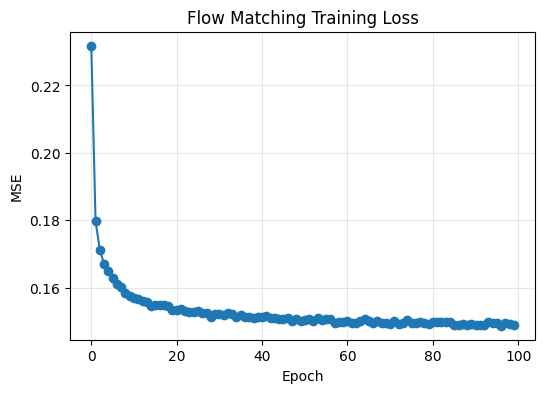

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(history, marker="o")
plt.title("Flow Matching Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)
plt.show()

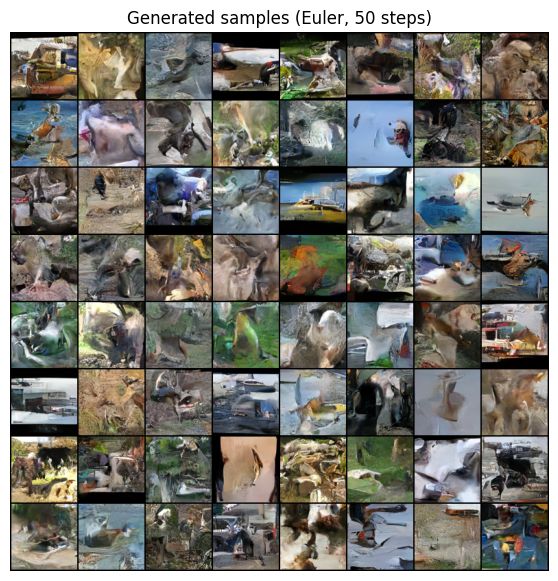

In [13]:
@torch.no_grad()
def euler_sample(model: nn.Module, n_samples: int = 64, steps: int = 50):
    """Role: generate new images by integrating the learned ODE from noise to data."""
    model.eval()
    # CNF dynamics from the paper's ODE formulation (Section 2): dX_t/dt = v_theta(X_t, t)

    # Start from pure Gaussian noise at t=0
    x = torch.randn(n_samples, 3, cfg.image_size, cfg.image_size, device=device)
    dt = 1.0 / steps

    for k in range(steps):
        t = torch.full((n_samples,), k / steps, device=device)
        v = model(x, t)
        # Explicit Euler discretization of the ODE
        x = x + dt * v

    return x.clamp(-1, 1)


@torch.no_grad()
def show_images(x: torch.Tensor, nrow: int = 8, title: str = ""):
    """Role: display a batch of images as a clean grid for quick visual checks."""
    # Convert back from [-1, 1] to [0, 1] for plotting
    x = (x + 1.0) / 2.0
    grid = make_grid(x.cpu(), nrow=nrow)
    plt.figure(figsize=(7, 7))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title(title)
    plt.show()


vis_model = sample_model if ("sample_model" in globals() and cfg.use_ema) else model
samples = euler_sample(vis_model, n_samples=cfg.n_sample_vis, steps=cfg.sample_steps)
show_images(samples, title=f"Generated samples (Euler, {cfg.sample_steps} steps)")


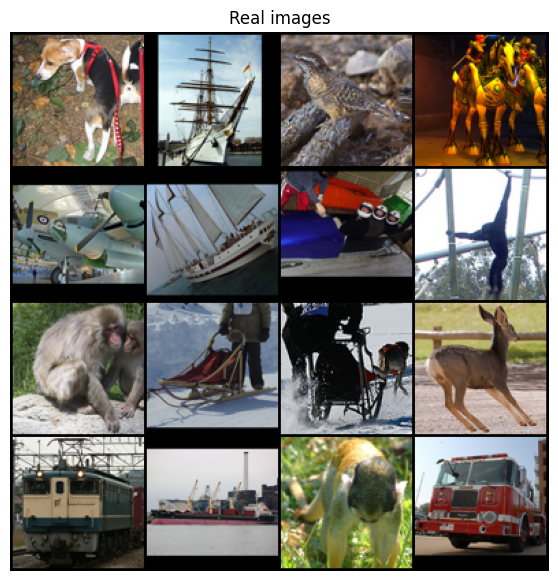

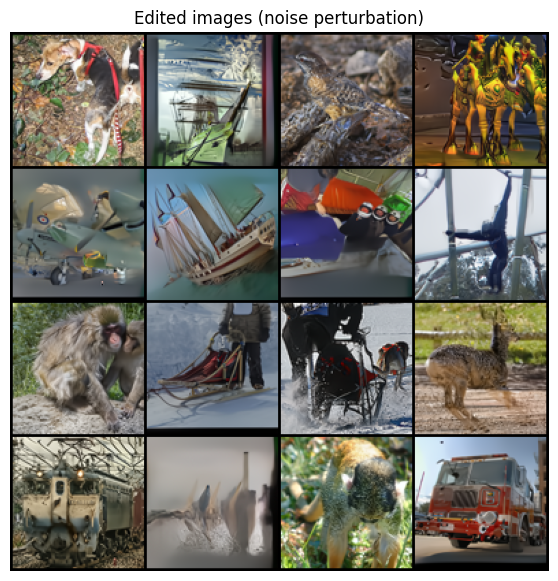

In [14]:
@torch.no_grad()
def invert_to_noise(model: nn.Module, x_real: torch.Tensor, steps: int = 50):
    """Role: approximately map real images back to a noise-like latent by reverse integration."""
    model.eval()
    # Reverse-time integration of the same learned ODE (used here for inversion/editing demo)
    x = x_real.clone()
    dt = 1.0 / steps
    b = x.size(0)

    for k in reversed(range(steps)):
        t = torch.full((b,), (k + 1) / steps, device=x.device)
        v = model(x, t)
        x = x - dt * v

    # This is approximate (finite steps + imperfect model)
    return x


@torch.no_grad()
def integrate_forward_from_noise(model: nn.Module, z: torch.Tensor, steps: int = 50):
    """Role: decode a latent/noise tensor into image space with forward ODE integration."""
    model.eval()
    x = z.clone()
    dt = 1.0 / steps
    b = x.size(0)

    for k in range(steps):
        t = torch.full((b,), k / steps, device=x.device)
        v = model(x, t)
        x = x + dt * v

    return x.clamp(-1, 1)


# Demo: invert a few real images, perturb latent noise, regenerate
x_real, _ = next(iter(train_loader))
x_real = x_real[:16].to(device)

z_est = invert_to_noise(model, x_real, steps=cfg.sample_steps)
z_edit = z_est + 0.2 * torch.randn_like(z_est)
x_edit = integrate_forward_from_noise(model, z_edit, steps=cfg.sample_steps)

show_images(x_real, nrow=4, title="Real images")
show_images(x_edit, nrow=4, title="Edited images (noise perturbation)")